# Predicting Content Virality on YouTube/TikTok
## Binary Classification: Predicting "Rising" Content Trends (2025)

**Target Variable:** `target = (trend_label == "rising").astype(int)`

---
This project implements a supervised binary classification framework to predict the virality of social media content. By leveraging metadata and performance metrics from YouTube and TikTok, the model aims to distinguish between "rising" content—classified as viral—and non-viral content. The analysis adheres to a rigorous machine learning lifecycle, prioritizing methodological integrity, data quality, and model interpretability.


## 1 Environment Setup

All library imports and environment configurations are consolidated in this section to ensure the notebook's reproducibility and streamline the dependency management process

### 1.1 Imports

In [1]:
# -- Paths --- 
from pathlib import Path

# --- Data manipulation ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics test ---
from scipy.stats import chi2_contingency, mannwhitneyu

# --- Scikit-Learn: partitioning e validation ---
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# --- Scikit-Learn: preprocessing e pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Scikit-Learn: models ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# --- Scikit-Learn: metrics ---
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, classification_report,
)

# --- Explainable AI ---
import shap

### 1.2 Configuration

In [2]:
# --- Replicability ---
RANDOM_STATE = 107

# --- Visualization settings ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_STATE)

print("Setup completed.")
print(f"  pandas : {pd.__version__}")
print(f"  numpy  : {np.__version__}")
print(f"  shap   : {shap.__version__}")

Setup completed.
  pandas : 3.0.3
  numpy  : 2.4.6
  shap   : 0.52.0


## 2. Data ingestion & Partitionig

The partitioning is carried out immediately after loading, prior to any in-depth inspection, imputation, or scaling.The reason is methodological. 

The split is stratified on the target to preserve class proportions. 

One column is removed prior to any other consideration: row_id — a unique identifier. It conveys no generalizable information and, in a tree-based model, only provides opportunities to memorize the Training Set.

### 2.1 Data import

In [3]:
# --- Dataset import ---
dataset_path = Path("Data") / "raw_tiktok_youtube_trends.csv"
datadict_path = Path("Data") / "DATA_DICTIONARY.csv"

df_raw = pd.read_csv(dataset_path, encoding="utf-8-sig")
data_dictionary = pd.read_csv(datadict_path)

print(f"Raw dataset dimensions: {df_raw.shape[0]} righe x {df_raw.shape[1]} colonne")
df_raw.head(10)

Raw dataset dimensions: 48079 righe x 58 colonne


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.120069,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.012555,0.007830,0.013525,21.497036,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,04/01/2025,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.113005,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.007850,0.007791,0.012067,35.182927,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,01/01/2025,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.068111,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.004469,0.005146,0.009343,27.923077,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,05/01/2025,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,1,36,72377,6243,811,383,391,0.108156,declining,Open Web Samples,cinematic b-roll,Android,15,Gaming,10,Medium,7237.70,229,0.011205,0.005292,0.005402,27.143478,Friday,Afternoon,SummerBreak,"fps, esports, clips, gaming, valorant, highlights",Can’t stop watching 😂,102133.2,Mid,Summer,03/01/2025,2025-01,Pro Tips for Valorant in 60s 🎮,30,1,23.7,0.658,Huawei,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,1,35,16174,832,68,67,204,0.072400,seasonal,TikTok Creative Center,text-to-speech,Android,18,Comedy,6,Short,2695.67,19,0.004204,0.004142,0.012613,41.600000,Saturday,Evening,Regular,"comedy, relatable, sketch",So underrated!,87549.4,Mid,Fall,04/01/2025,2025-01,POV: Budget 😂,13,1,24.6,0.703,Huawei,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142
5,TikTok,Ke,Africa,sw,Art,#FYP,I flipped this sample,DanceWithAhmed,licensed,Indie brush,1,33,47449,2462,254,245,155,0.065671,seasonal,TikTok Creative Center,facecam,Android,18,Music,12,Medium,3954.08,83,0.005353,0.005163,0.003267,29.309524,Friday,Evening,Regular,"beat, music, song, cover",This is fire 🔥,96805.5,Mid,Fall,03/01/2025,2025-01,I flipped this sample 🧠,23,1,18.1,0.548,iPhone,Search,1,a2100bd7c9b924b156281885148c33f8,3116,0.051887,0.001749,65.671,0.051887,0.005353,0.005163
6,TikTok,Us,North America,en,Food,#Travel,Hidden Gems of New York,ProJiwoo,licensed,Sizzle ASMR,1,26,27099,1868,257,218,306,0.097753,rising,TikTok Creative Center,fast captions,iOS,21,Travel,19,Medium,1426.26,51,0.009484,

### 2.2 Split Train/Test

In [23]:
# --- Target definition
df_raw["target"] = (df_raw["trend_label"] == "rising").astype(int) 

# --- Deletion of 'row-id', 'trend_label' columns---
df = df_raw.drop(columns=["row_id", "trend_label"])

# --- Deduplication ---
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicated rows removed: {n_duplicates}")

# --- Split of predictors / target ---
X = df.drop(columns=["target"])
y = df["target"]

# --- Stratified split 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_STATE,
)

print(f"\nTraining Set : {X_train.shape[0]} rows")
print(f"Test Set     : {X_test.shape[0]} rows")
print(f"Target/Train proportion: {y_train.mean()*100:.3f} %  || test: {y_test.mean()*100:.3f} %")

Duplicated rows removed: 0

Training Set : 38463 rows
Test Set     : 9616 rows
Target/Train proportion: 25.172 %  || test: 25.166 %


## 3 Exploratory Data Analysis & Data Quality

All subsequent EDA is conducted exclusively on the Training Set. 

In [24]:
# --- General structure of Training Set ---
print("=" * 60)
print("General info")
print("=" * 60)
X_train.info(verbose=True, show_counts=True)

print("\n" + "=" * 60)
print("Preview")
print("=" * 60)
display(X_train.head())

General info
<class 'pandas.DataFrame'>
Index: 38463 entries, 8224 to 1692
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 38463 non-null  str    
 1   country                  38463 non-null  str    
 2   region                   38463 non-null  str    
 3   language                 38463 non-null  str    
 4   category                 38463 non-null  str    
 5   hashtag                  38463 non-null  str    
 6   title_keywords           38463 non-null  str    
 7   author_handle            38463 non-null  str    
 8   sound_type               38463 non-null  str    
 9   music_track              38463 non-null  str    
 10  week_of_year             38463 non-null  int64  
 11  duration_sec             38463 non-null  int64  
 12  views                    38463 non-null  int64  
 13  likes                    38463 non-null  int64  
 14  comments               

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
8224,TikTok,Tr,Europe,tr,Art,#Beauty,Skincare routine for Summer,FitnessWithOlivia,trending,Gallery pad,7,44,130143,12304,1130,1333,777,0.119438,TikTok Creative Center,b-roll heavy,iOS,14,Beauty,10,Medium,13014.30,96,0.008683,0.010243,0.005970,126.845361,Friday,Afternoon,Regular,"makeup, grwm, beauty",Instant like!,127785.3,Mid,Spring,14/02/2025,2025-02,Makeup Basics You Need 🍔,24,1,26.7,0.607,iPhone,ForYou,1,15544,0.094542,0.000738,119.438,0.094542,0.008683,0.010243
19083,TikTok,In,Asia,hi,Beauty,#Relatable,If 2025 was honest,MusicByLina,original,LoFi makeup beat,15,35,164135,10686,1472,1227,704,0.085838,TikTok Creative Center,cinematic b-roll,iOS,16,Comedy,19,Medium,8638.68,431,0.008968,0.007476,0.004289,24.736111,Friday,Afternoon,Regular,"sketch, comedy, funny",Can’t stop watching 😂,140206.0,Mid,Spring,11/04/2025,2025-04,When your friend is Beginners ⚽,31,1,21.1,0.603,Samsung,ForYou,1,14089,0.065105,0.002626,85.838,0.065105,0.008968,0.007476
18025,YouTube,Gb,Europe,en,Sports,#Music,I flipped this sample,TravelByDiego,trending,Stadium chant,14,36,27376,1478,186,176,96,0.070719,Public Reports,storytime,Android,17,Music,10,Medium,2737.60,97,0.006794,0.006429,0.003507,15.081633,Sunday,Evening,HolidaySeason,"music, beat, song",Instant like!,74831.7,Mid,Winter,06/04/2025,2025-04,I flipped this sample,21,0,15.7,0.436,Xiaomi,Home,1,1936,0.053989,0.003543,70.719,0.053989,0.006794,0.006429
27239,YouTube,It,Europe,it,Lifestyle,#MorningRoutine,Morning Routine — 2025,HassanYT,original,Morning vibe,20,48,36679,1104,139,108,71,0.038769,TikTok Creative Center,split-screen,Web,17,Lifestyle,54,Evergreen,679.24,29,0.003790,0.002944,0.001936,36.800000,Wednesday,Evening,Regular,"lifestyle, motivation, daily",Can’t stop watching 😂,88981.6,Mid,Spring,14/05/2025,2025-05,Morning Routine — Productivity,30,0,19.3,0.402,Desktop,External,0,1422,0.030099,0.000791,38.769,0.030099,0.003790,0.002944
30094,TikTok,Sa,Asia,ar,Fitness,#Relatable,POV: 2025,CookingWithNoor,trending,HIIT drums,23,70,1547678,82392,8667,6898,17355,0.074506,Public Reports,text-to-speech,iOS,7,Comedy,11,Medium,140698.00,2922,0.005600,0.004457,0.011214,28.187479,Saturday,Morning,SummerBreak,"comedy, funny, relatable, sketch",تحفة بصراحة!,113141.1,Mid,Summer,07/06/2025,2025-06,If Beginners was honest ✨,25,1,50.4,0.720,Samsung,ForYou,1,115312,0.053236,0.001888,74.506,0.053236,0.005600,0.004457


In [25]:
# --- Summary ---
riepilogo = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "n_unique": X_train.nunique(),
    "n_missing": X_train.isna().sum(),
    "perc_missing": (X_train.isna().mean() * 100).round(2),
})
print("Summary:")
display(riepilogo.sort_values("n_unique", ascending=False))

print("\n" + "=" * 110)
print("Descriptive Statistics of Numeric Features")
print("=" * 110)
display(X_train.describe().T.round(3))

Summary:


,dtype,n_unique,n_missing,perc_missing
engagement_like_rate,float64,38434,0,0.0
engagement_comment_rate,float64,38242,0,0.0
engagement_share_rate,float64,38181,0,0.0
engagement_velocity,float64,37431,0,0.0
like_dislike_ratio,float64,35084,0,0.0
views,int64,34384,0,0.0
engagement_per_1k,float64,32119,0,0.0
engagement_rate,float64,32119,0,0.0
like_rate,float64,30702,0,0.0
engagement_total,int64,15455,0,0.0



Descriptive Statistics of Numeric Features


,count,mean,std,min,25%,50%,75%,max
week_of_year,38463.0,18.248,10.004,1.000,10.000,18.000,27.000,35.000
duration_sec,38463.0,34.409,16.376,5.000,22.000,31.000,43.000,90.000
views,38463.0,99191.475,131762.860,794.000,30499.500,59554.000,117510.500,3037808.000
likes,38463.0,5739.065,8617.281,33.000,1532.000,3165.000,6629.000,310916.000
comments,38463.0,628.885,967.713,3.000,160.000,338.000,721.000,31776.000
shares,38463.0,553.605,853.129,3.000,144.000,301.000,636.000,29004.000
saves,38463.0,591.797,970.308,2.000,138.000,300.000,664.500,29679.000
engagement_rate,38463.0,0.076,0.030,0.015,0.052,0.072,0.095,0.226
upload_hour,38463.0,15.995,5.488,0.000,13.000,17.000,20.000,23.000
trend_duration_days,38463.0,13.764,13.396,3.000,5.000,7.000,17.000,60.000


### 3.1 Missing values handling

The following cell also checks for masked missing values: values such as "NA", "unknown", "-", or "" that pandas reads as valid strings, meaning they would not show up in the NaN count.

In [26]:
# --- Explicit missing values---
missing = X_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No NaN values are in the Training Set.")
else:
    print("Explicit missing values:")
    display(pd.DataFrame({"n_missing": missing,"perc": (missing / len(X_train) * 100).round(2)}))

# --- Masked missing values ---
sentinels = {"NA", "N/A", "n/a", "na", "unknown", "Unknown", "UNKNOWN", "-", "",
              "null", "NULL", "None", "?", "missing", "nan", "NaN", "undefined"}

found = {}
for col in X_train.columns:
    if X_train[col].dtype == object or str(X_train[col].dtype) == "str":
        contain = set(X_train[col].dropna().astype(str).str.strip().unique()) & sentinels
        if contain:
            found[col] = contain

if found:
    print("\nMasked missing values:")
    for col, vals in found.items():
        print(f"  {col:<24} -> {vals}")
else:
    print("\nNo Masked missing values are in the Training Set.")

No NaN values are in the Training Set.

No Masked missing values are in the Training Set.


### 3.2 Algebraic Redundancy Audit

Before analyzing distributions, it is useful to verify which columns are deterministic functions of others. 

The verification is algebraic rather than statistical: values are compared against the expected formula, and the maximum error is observed.

In [27]:
# --- Checking suspected identities among derived columns ---
eps = 1e-4
identity = {
    "engagement_total == likes + comments + shares + saves":
        (X_train[["likes", "comments", "shares", "saves"]].sum(axis=1) - X_train["engagement_total"]).abs().max(),
    "engagement_rate == engagement_total / views":
        (X_train["engagement_total"] / X_train["views"] - X_train["engagement_rate"]).abs().max(),
    "engagement_per_1k == engagement_rate * 1000":
        (X_train["engagement_rate"] * 1000 - X_train["engagement_per_1k"]).abs().max(),
    "like_rate == likes / views":
        (X_train["likes"] / X_train["views"] - X_train["like_rate"]).abs().max(),
    "comment_ratio == comments / views":
        (X_train["comments"] / X_train["views"] - X_train["comment_ratio"]).abs().max(),
    "share_rate == shares / views":
        (X_train["shares"] / X_train["views"] - X_train["share_rate"]).abs().max(),
    "save_rate == saves / views":
        (X_train["saves"] / X_train["views"] - X_train["save_rate"]).abs().max(),
    "dislike_rate == dislikes / views":
        (X_train["dislikes"] / X_train["views"] - X_train["dislike_rate"]).abs().max(),
    "completion_rate == avg_watch_time_sec / duration_sec":
        (X_train["avg_watch_time_sec"] / X_train["duration_sec"] - X_train["completion_rate"]).abs().max(),
    "engagement_rate == like_rate + comment_ratio + share_rate + save_rate":
        (X_train[["like_rate", "comment_ratio", "share_rate", "save_rate"]].sum(axis=1)
         - X_train["engagement_rate"]).abs().max(),
}

result = pd.DataFrame(
    [(k, v, "Perfect identity" if v < eps else "not exact") for k, v in identity.items()],
    columns=["Verified relation", "max_error", "result"],
)
display(result)

,Verified relation,max_error,result
0,engagement_total == likes + comments + shares ...,0.000000e+00,Perfect identity
1,engagement_rate == engagement_total / views,5.000000e-07,Perfect identity
2,engagement_per_1k == engagement_rate * 1000,2.842171e-14,Perfect identity
3,like_rate == likes / views,5.000000e-07,Perfect identity
4,comment_ratio == comments / views,5.000000e-07,Perfect identity
5,share_rate == shares / views,5.000000e-07,Perfect identity
6,save_rate == saves / views,5.000000e-07,Perfect identity
7,dislike_rate == dislikes / views,5.000000e-07,Perfect identity
8,completion_rate == avg_watch_time_sec / durati...,5.000000e-04,not exact
9,engagement_rate == like_rate + comment_ratio +...,2.000000e-06,Perfect identity


The relations marked as exact identities confirm that the engagement metrics block is internally redundant: `engagement_rate`, `engagement_per_1k`, `like_rate`, `comment_ratio`, `share_rate`, and `save_rate` are bound by an exact linear relationship. Including all of them in the model would introduce perfect collinearity with zero informational gain.

### 3.3 Target Distribution and Predictive Power Audit

Three complementary tools are employed:
- **Univariate AUROC**
- **Chi-Square Test of Independence**
- **Mann-Whitney U Test**

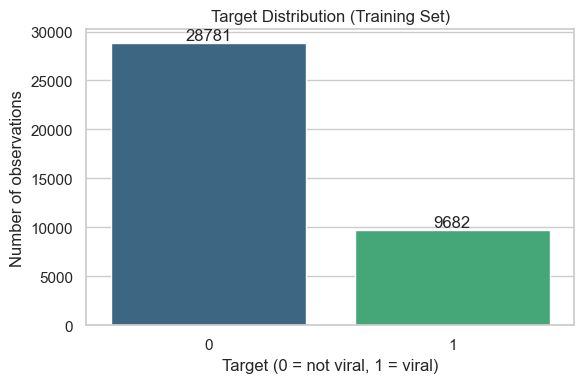

Positive class prevalence: 25.17%
Imbalance ratio (negatives : positives) = 2.97 : 1

Dataset treated as imbalanced: True


In [28]:
# --- Target distribution ---
counts = y_train.value_counts().sort_index()
positive_prevalence = y_train.mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax,
            hue=counts.index, palette="viridis", legend=False)
ax.set_title("Target Distribution (Training Set)")
ax.set_xlabel("Target (0 = not viral, 1 = viral)")
ax.set_ylabel("Number of observations")

for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive class prevalence: {positive_prevalence:.2%}")
imbalance_ratio = (1 - positive_prevalence) / positive_prevalence
print(f"Imbalance ratio (negatives : positives) = {imbalance_ratio:.2f} : 1")

is_imbalanced = not (0.40 <= positive_prevalence <= 0.60)
print(f"\nDataset treated as imbalanced: {is_imbalanced}")

The target is derived from a 4-level variable that is approximately evenly distributed:
the positive class therefore accounts for about a quarter of the total. The imbalance is moderate, not extreme, but sufficient to make accuracy an unreliable metric.

In [29]:
# --- Systematic Audit of Univariate Predictive Power ---

# AUROC
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in X_train.columns if c not in numerical_columns]

rows = []
for col in numerical_columns:
    auc = roc_auc_score(y_train, X_train[col])
    stat, p_val = mannwhitneyu(X_train.loc[y_train == 1, col],
                               X_train.loc[y_train == 0, col],
                               alternative="two-sided")
    rows.append({"variable": col, "type": "numerical",
                  "univariate_auroc": max(auc, 1 - auc), "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

for col in categorical_columns:
    table = pd.crosstab(X_train[col], y_train)
    chi2, p_val, dof, expected = chi2_contingency(table)
    rows.append({"variable": col, "type": "categorical",
                  "univariate_auroc": np.nan, "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

audit = pd.DataFrame(rows).sort_values("p_value")
audit["significant_5pct"] = audit["p_value"] < 0.05

print("Univariate predictive power audit:")
display(audit.round(4))

n_signif = int(audit["significant_5pct"].sum())
n_total = len(audit)
expected_by_chance = 0.05 * n_total

print(f"\nVariables significant at 5%: {n_signif} out of {n_total}")
print(f"Expected number by pure chance (false positives): {expected_by_chance:.1f}")

Univariate predictive power audit:


,variable,type,univariate_auroc,p_value,n_levels,significant_5pct
49,creator_tier,categorical,NaN,0.0804,2,False
39,source_hint,categorical,NaN,0.1170,3,False
33,category,categorical,NaN,0.1178,19,False
45,publish_period,categorical,NaN,0.1193,4,False
0,week_of_year,numerical,0.5052,0.1220,35,False
38,music_track,categorical,NaN,0.1302,61,False
55,traffic_source,categorical,NaN,0.1508,6,False
43,trend_type,categorical,NaN,0.1697,3,False
16,creator_avg_views,numerical,0.5041,0.2280,720,False
50,season,categorical,NaN,0.2415,4,False



Variables significant at 5%: 0 out of 56
Expected number by pure chance (false positives): 2.8


If the number of 'significant' variables is of the same order of magnitude as those expected by pure chance, there is no evidence of a systematic relationship between predictors and target. When testing dozens of variables at 5%, some will turn out significant by definition: this is the multiple testing problem, not a signal.

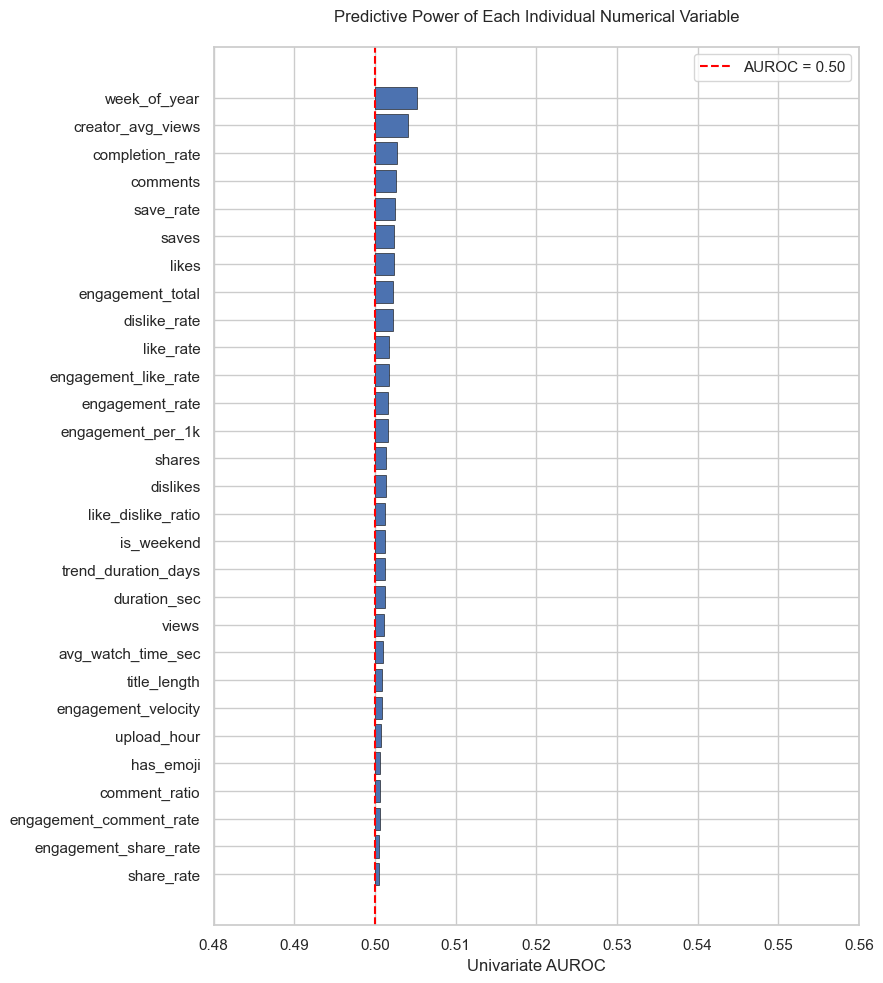

Maximum observed univariate AUROC: 0.5052
No numerical variable deviates appreciably from 0.50.

Pearson Correlation with the Target:


,correlation
dislikes,0.0124
saves,0.0092
likes,0.0088
engagement_total,0.0085
week_of_year,0.0079
engagement_velocity,0.0078
views,0.0072
comments,0.0065
creator_avg_views,-0.0058
shares,0.0056


Maximum absolute correlation: 0.0124


In [32]:
# --- Graphical Representation of the Audit ---
audit_num = audit[audit["type"] == "numerical"].sort_values("univariate_auroc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(audit_num["variable"], audit_num["univariate_auroc"] - 0.5,
        left=0.5, color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5,
           label="AUROC = 0.50")
ax.set_xlim(0.48, 0.56)
ax.set_xlabel("Univariate AUROC")
ax.set_title("Predictive Power of Each Individual Numerical Variable\n")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Maximum observed univariate AUROC: {audit_num['univariate_auroc'].max():.4f}")
print("No numerical variable deviates appreciably from 0.50.")

# --- Correlation Matrix with the Target ---
corr_target = X_train[numerical_columns].corrwith(y_train).sort_values(key=abs, ascending=False)

print("\nPearson Correlation with the Target:")
display(corr_target.head(10).round(4).to_frame("correlation"))
print(f"Maximum absolute correlation: {corr_target.abs().max():.4f}")